# Noise Models Comparison — Gaussian vs. Spatially Correlated

EQ-INSAR v0.2.0 ships two noise models:

| Model | `noise_model=` | Description |
|---|---|---|
| Gaussian | `'gaussian'` | Uncorrelated white noise, $\mathcal{N}(0,\sigma^2)$ |
| Correlated | `'correlated'` | Power-law PSD, $P(f) \propto f^{-\beta}$, default $\beta = 5/3$ (Kolmogorov) |

This notebook shows:
1. Pure noise fields — what each model looks like
2. Power spectral density — the quantitative difference
3. Effect of the spectral index $\beta$
4. Single interferogram — same earthquake, both noise models
5. Time series — label masks under both models
6. Batch sample gallery

In [1]:
import sys, os

if 'google.colab' in sys.modules:
    os.system('pip install eq-insar -q')
else:
    # Use local development source when running from the repo
    sys.path.insert(0, os.path.join('..', 'src'))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

from eq_insar import (
    generate_random_noise,
    generate_correlated_noise,
    generate_synthetic_insar,
    generate_timeseries,
    generate_training_batch,
    batch_to_arrays,
)

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
})

SHAPE = (256, 256)
AMP   = 0.005   # 5 mm noise amplitude
SEED  = 42

print('EQ-INSAR noise model comparison — ready')

EQ-INSAR noise model comparison — ready


---
## 1. Pure noise fields

Both models produce zero-mean noise with the same standard deviation (`amplitude_m`).  
The visual difference is immediately apparent: Gaussian noise looks like television static, while correlated noise has the long-range "haze" pattern seen in real InSAR atmospheric delay maps.

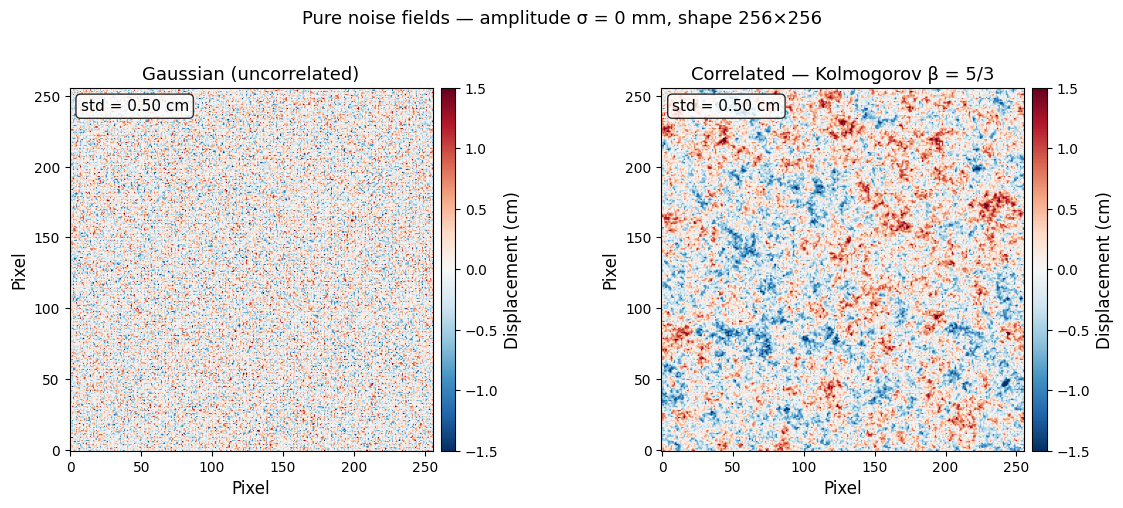

In [3]:
gauss = generate_random_noise(SHAPE, amplitude_m=AMP, seed=SEED)
corr  = generate_correlated_noise(SHAPE, amplitude_m=AMP, beta=5/3, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(axes,
                            [gauss, corr],
                            ['Gaussian (uncorrelated)', 'Correlated — Kolmogorov β = 5/3']):
    im = ax.imshow(data * 100, cmap='RdBu_r',
                   vmin=-AMP*3*100, vmax=AMP*3*100,
                   origin='lower', aspect='equal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Pixel')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.08)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label('Displacement (cm)')
    ax.text(0.03, 0.97, f'std = {data.std()*100:.2f} cm',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.suptitle(f'Pure noise fields — amplitude σ = {AMP*100:.0f} mm, shape {SHAPE[0]}×{SHAPE[1]}',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Power spectral density

The 2-D radially-averaged PSD makes the difference quantitative.  
Gaussian noise has a flat (white) spectrum. Correlated noise follows $P(f) \propto f^{-\beta}$,  
so low spatial frequencies (large-scale structure) carry most of the power.

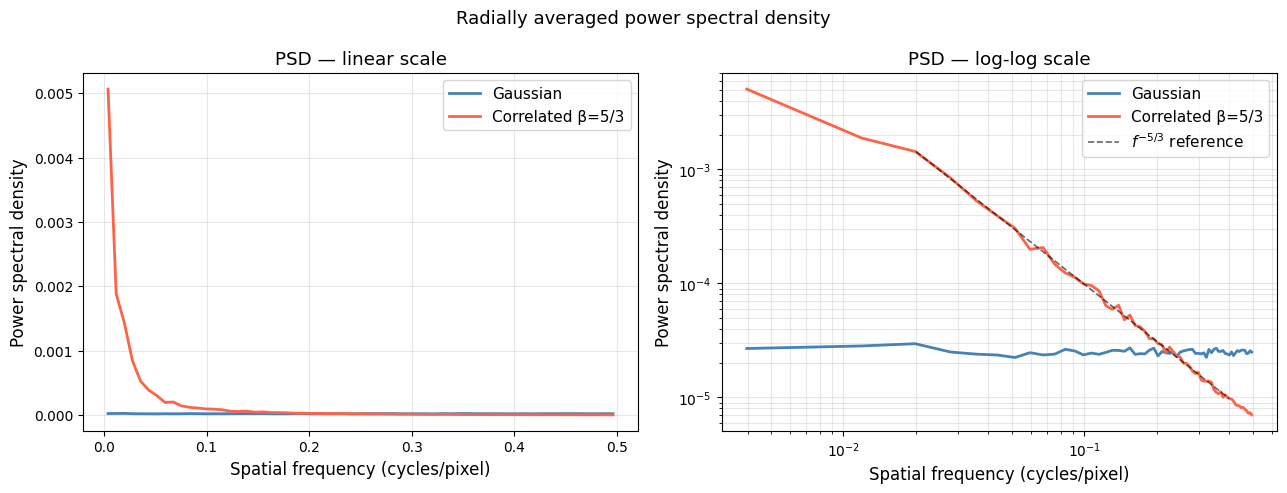

In [4]:
def radial_psd(field):
    """Radially averaged 2-D power spectral density."""
    ny, nx = field.shape
    F = np.fft.fft2(field)
    P = (np.abs(F) ** 2) / (ny * nx)
    fy = np.fft.fftfreq(ny)
    fx = np.fft.fftfreq(nx)
    FX, FY = np.meshgrid(fx, fy)
    freq = np.sqrt(FX**2 + FY**2).ravel()
    power = P.ravel()
    # bin by frequency
    f_bins = np.linspace(0, 0.5, 64)
    f_mid  = 0.5 * (f_bins[:-1] + f_bins[1:])
    p_mean = np.array([
        power[(freq >= f_bins[i]) & (freq < f_bins[i+1])].mean()
        if ((freq >= f_bins[i]) & (freq < f_bins[i+1])).any() else np.nan
        for i in range(len(f_bins)-1)
    ])
    mask = np.isfinite(p_mean) & (f_mid > 0)
    return f_mid[mask], p_mean[mask]

fg, pg = radial_psd(gauss)
fc, pc = radial_psd(corr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
axes[0].plot(fg, pg, 'steelblue', lw=2, label='Gaussian')
axes[0].plot(fc, pc, 'tomato',    lw=2, label='Correlated β=5/3')
axes[0].set_xlabel('Spatial frequency (cycles/pixel)')
axes[0].set_ylabel('Power spectral density')
axes[0].set_title('PSD — linear scale')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log-log scale — power-law slope visible
axes[1].loglog(fg, pg, 'steelblue', lw=2, label='Gaussian')
axes[1].loglog(fc, pc, 'tomato',    lw=2, label='Correlated β=5/3')
# Reference slope line
f_ref = np.array([0.02, 0.4])
axes[1].loglog(f_ref, pc[np.argmin(np.abs(fc - 0.02))] * (f_ref / 0.02)**(-5/3),
               'k--', lw=1.2, alpha=0.6, label=r'$f^{-5/3}$ reference')
axes[1].set_xlabel('Spatial frequency (cycles/pixel)')
axes[1].set_ylabel('Power spectral density')
axes[1].set_title('PSD — log-log scale')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Radially averaged power spectral density', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Effect of the spectral index β

$\beta = 0$ → white noise (flat spectrum, visually identical to Gaussian).  
$\beta = 5/3$ → Kolmogorov atmospheric turbulence (default).  
$\beta = 8/3$ → steeper, dominated by very large-scale structure (stratified atmosphere).

All panels share the same amplitude and colour scale.

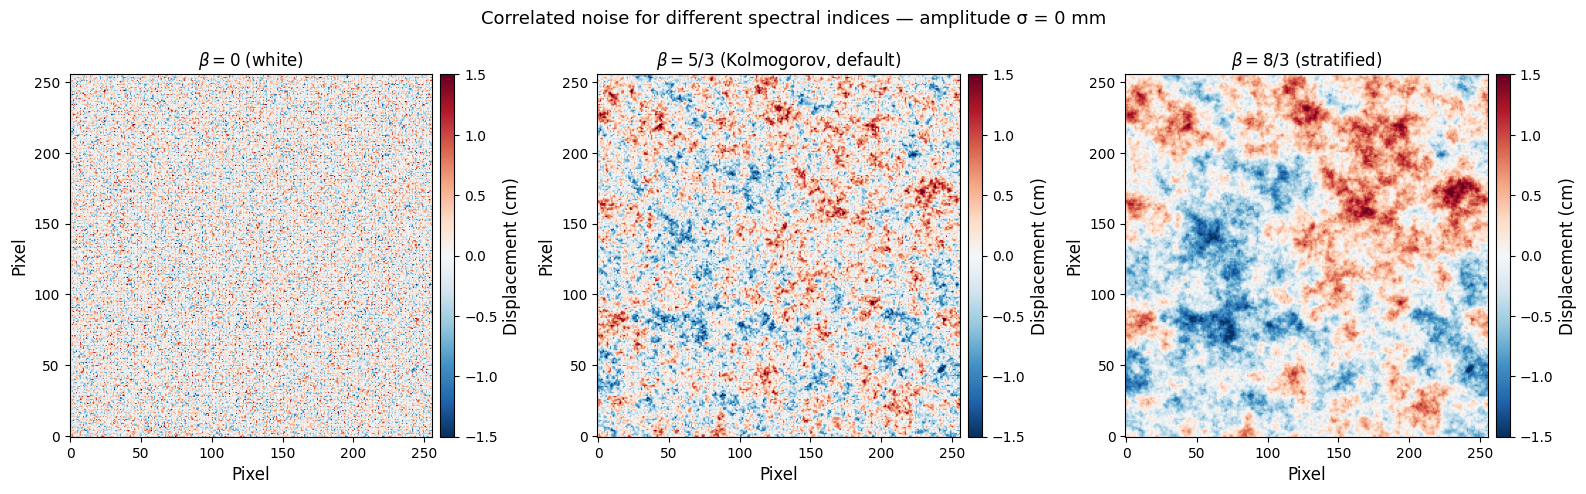

In [5]:
betas = [0.0, 5/3, 8/3]
labels = [r'$\beta = 0$ (white)', r'$\beta = 5/3$ (Kolmogorov, default)', r'$\beta = 8/3$ (stratified)']
fields = [generate_correlated_noise(SHAPE, amplitude_m=AMP, beta=b, seed=SEED) for b in betas]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vmax = AMP * 3 * 100

for ax, field, lbl in zip(axes, fields, labels):
    im = ax.imshow(field * 100, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   origin='lower', aspect='equal')
    ax.set_title(lbl, fontsize=12)
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Pixel')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.08)
    plt.colorbar(im, cax=cax, label='Displacement (cm)')

plt.suptitle(f'Correlated noise for different spectral indices — amplitude σ = {AMP*100:.0f} mm',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Single interferogram — same earthquake, both noise models

$M_w$ 6.0 thrust earthquake (strike 45°, dip 30°, rake 90°, depth 10 km),  
Sentinel-1 ascending geometry.

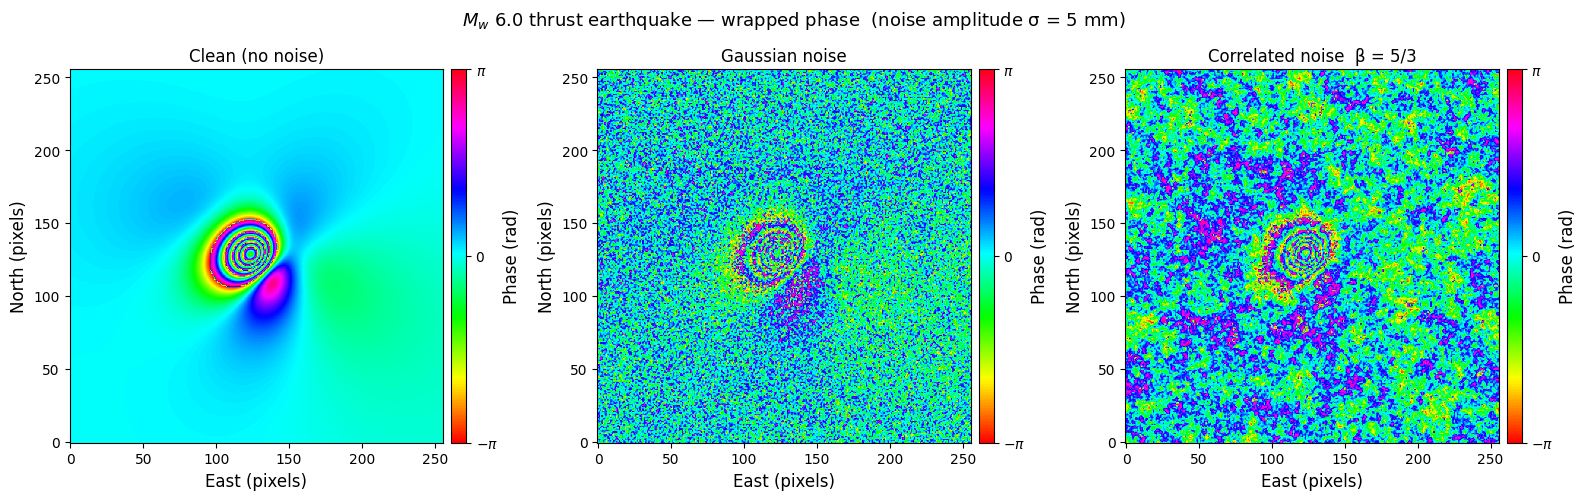

In [6]:
EQ_PARAMS = dict(
    Mw=6.0, strike_deg=45, dip_deg=30, rake_deg=90,
    depth_km=8, satellite='sentinel1', orbit='ascending',
    grid_size=256, noise_amplitude_m=AMP,
    wrap=True, seed=SEED,
)

res_gauss = generate_synthetic_insar(**EQ_PARAMS, add_noise=True, noise_model='gaussian')
res_corr  = generate_synthetic_insar(**EQ_PARAMS, add_noise=True, noise_model='correlated', noise_beta=5/3)
res_clean = generate_synthetic_insar(**EQ_PARAMS, add_noise=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Clean (no noise)', 'Gaussian noise', 'Correlated noise  β = 5/3']
panels = [res_clean['phase_wrapped'], res_gauss['phase_noisy'], res_corr['phase_noisy']]

for ax, data, title in zip(axes, panels, titles):
    im = ax.imshow(data, cmap='hsv', vmin=-np.pi, vmax=np.pi,
                   origin='lower', aspect='equal')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('East (pixels)')
    ax.set_ylabel('North (pixels)')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.08)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label('Phase (rad)')
    cb.set_ticks([-np.pi, 0, np.pi])
    cb.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])

plt.suptitle(r'$M_w$ 6.0 thrust earthquake — wrapped phase  (noise amplitude σ = 5 mm)',
             fontsize=13)
plt.tight_layout()
plt.savefig('noise_example.png')
plt.show()


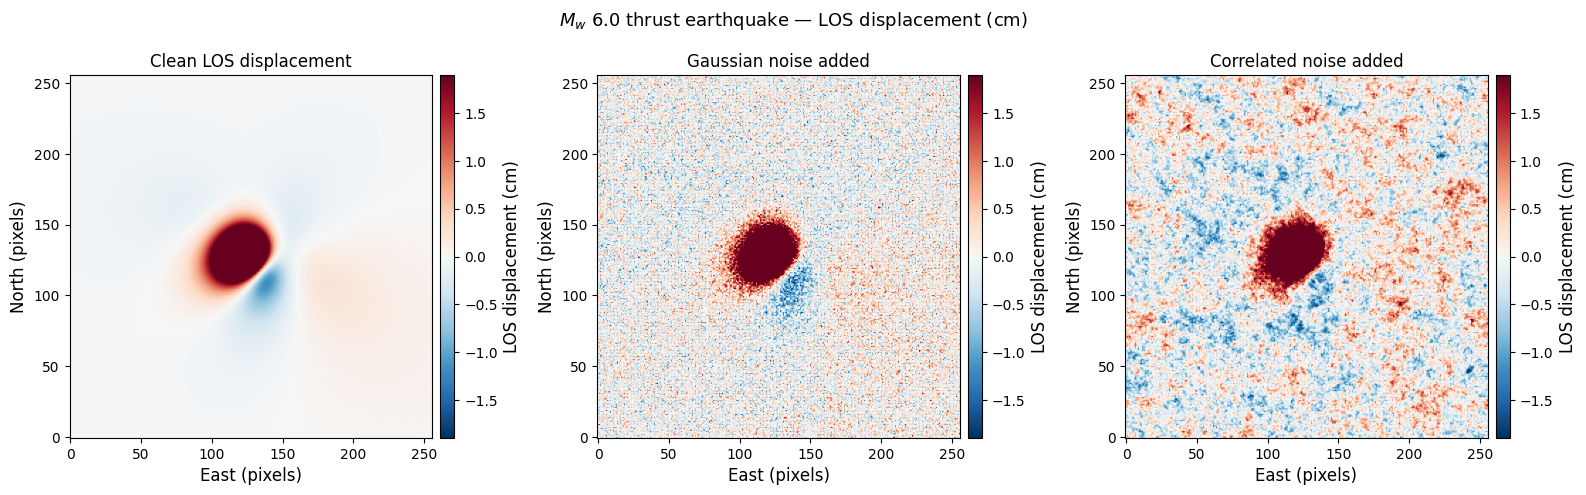

In [7]:
# LOS displacement comparison (unwrapped)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Clean LOS displacement', 'Gaussian noise added', 'Correlated noise added']
panels = [
    res_clean['los_displacement'] * 100,
    (res_clean['los_displacement'] + generate_random_noise((256,256), AMP, seed=SEED)) * 100,
    (res_clean['los_displacement'] + generate_correlated_noise((256,256), AMP, seed=SEED)) * 100,
]
vmax = np.nanpercentile(np.abs(panels[0]), 98)

for ax, data, title in zip(axes, panels, titles):
    im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   origin='lower', aspect='equal')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('East (pixels)')
    ax.set_ylabel('North (pixels)')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.08)
    plt.colorbar(im, cax=cax, label='LOS displacement (cm)')

plt.suptitle(r'$M_w$ 6.0 thrust earthquake — LOS displacement (cm)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Time series — segmentation labels under both noise models

Because the binary label mask is derived from the **noise-free** LOS displacement,  
it is identical regardless of which noise model is used.  
What changes is how realistic the input phase frames look to a trained model.

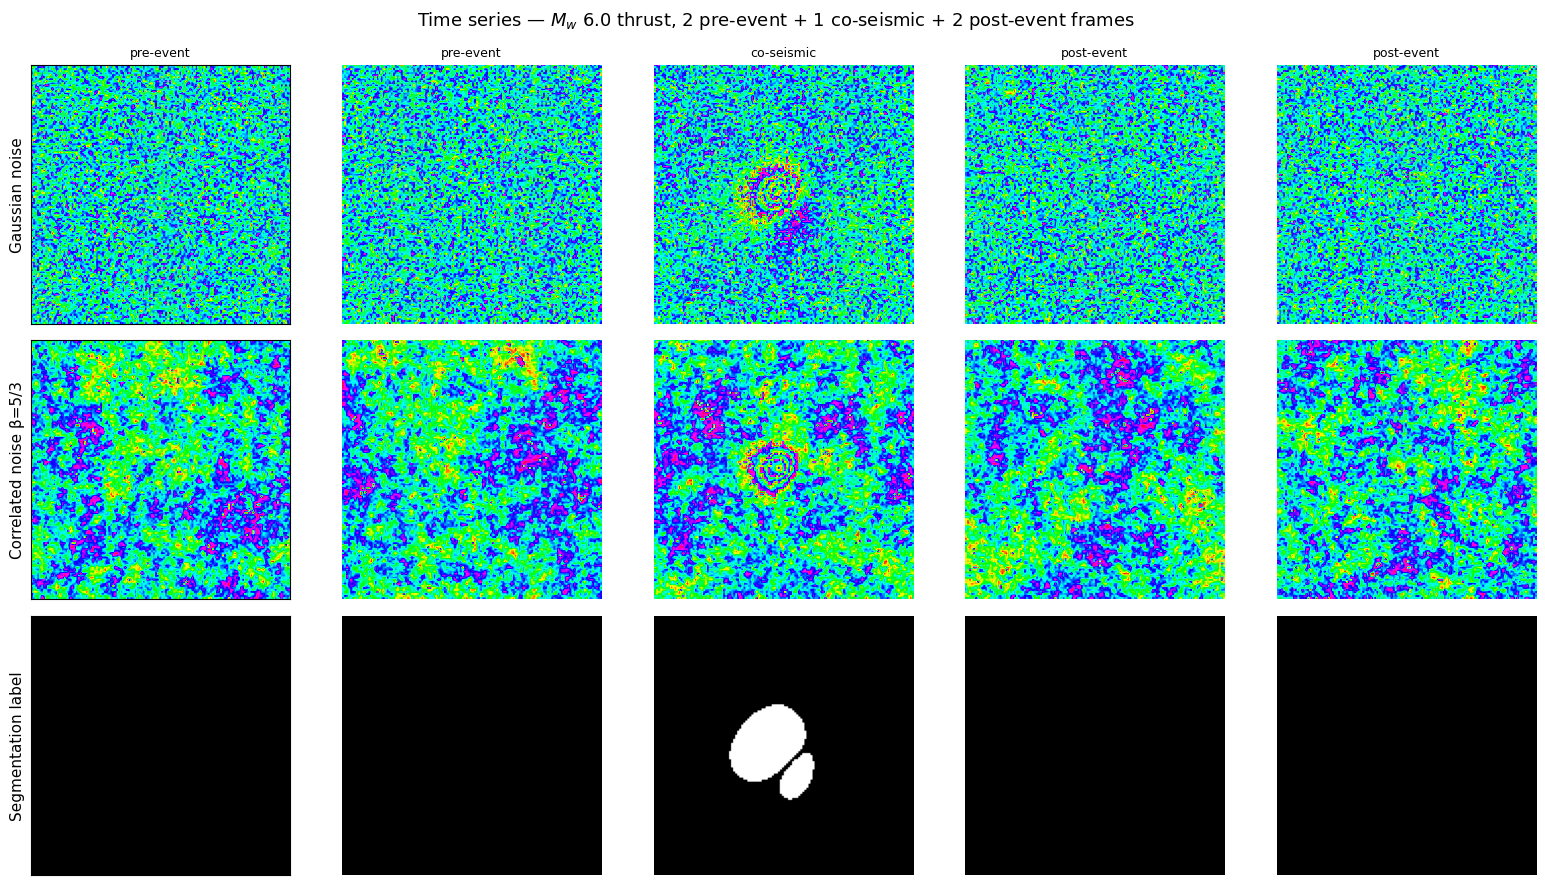

Label identical across noise models: True


In [8]:
TS_PARAMS = dict(
    Mw=6.0, strike_deg=45, dip_deg=30, rake_deg=90,
    depth_km=10, satellite='sentinel1', orbit='ascending',
    grid_size=128, n_pre=2, n_event=1, n_post=2,
    noise_amplitude_m=AMP, seed=SEED,
)

ts_gauss = generate_timeseries(**TS_PARAMS, noise_model='gaussian')
ts_corr  = generate_timeseries(**TS_PARAMS, noise_model='correlated', noise_beta=5/3)

n_total = ts_gauss['timeseries'].shape[0]  # 5
frame_labels = ['pre-event', 'pre-event', 'co-seismic', 'post-event', 'post-event']

fig, axes = plt.subplots(3, n_total, figsize=(16, 9))
row_titles = ['Gaussian noise', 'Correlated noise β=5/3', 'Segmentation label']
vph = np.pi

for t in range(n_total):
    # Gaussian
    axes[0, t].imshow(ts_gauss['timeseries'][t], cmap='hsv', vmin=-vph, vmax=vph,
                       origin='lower', aspect='equal')
    axes[0, t].set_title(frame_labels[t], fontsize=9)
    axes[0, t].axis('off')

    # Correlated
    axes[1, t].imshow(ts_corr['timeseries'][t], cmap='hsv', vmin=-vph, vmax=vph,
                       origin='lower', aspect='equal')
    axes[1, t].axis('off')

    # Label (identical for both)
    axes[2, t].imshow(ts_corr['labels'][t], cmap='Greys_r', vmin=0, vmax=1,
                       origin='lower', aspect='equal')
    axes[2, t].axis('off')

for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=11, labelpad=4)
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

plt.suptitle(r'Time series — $M_w$ 6.0 thrust, 2 pre-event + 1 co-seismic + 2 post-event frames',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Label identical across noise models:',
      np.array_equal(ts_gauss['labels'], ts_corr['labels']))

---
## 6. Batch sample gallery

Eight randomly generated co-seismic frames with correlated noise,  
spanning different magnitudes, depths, and fault orientations.

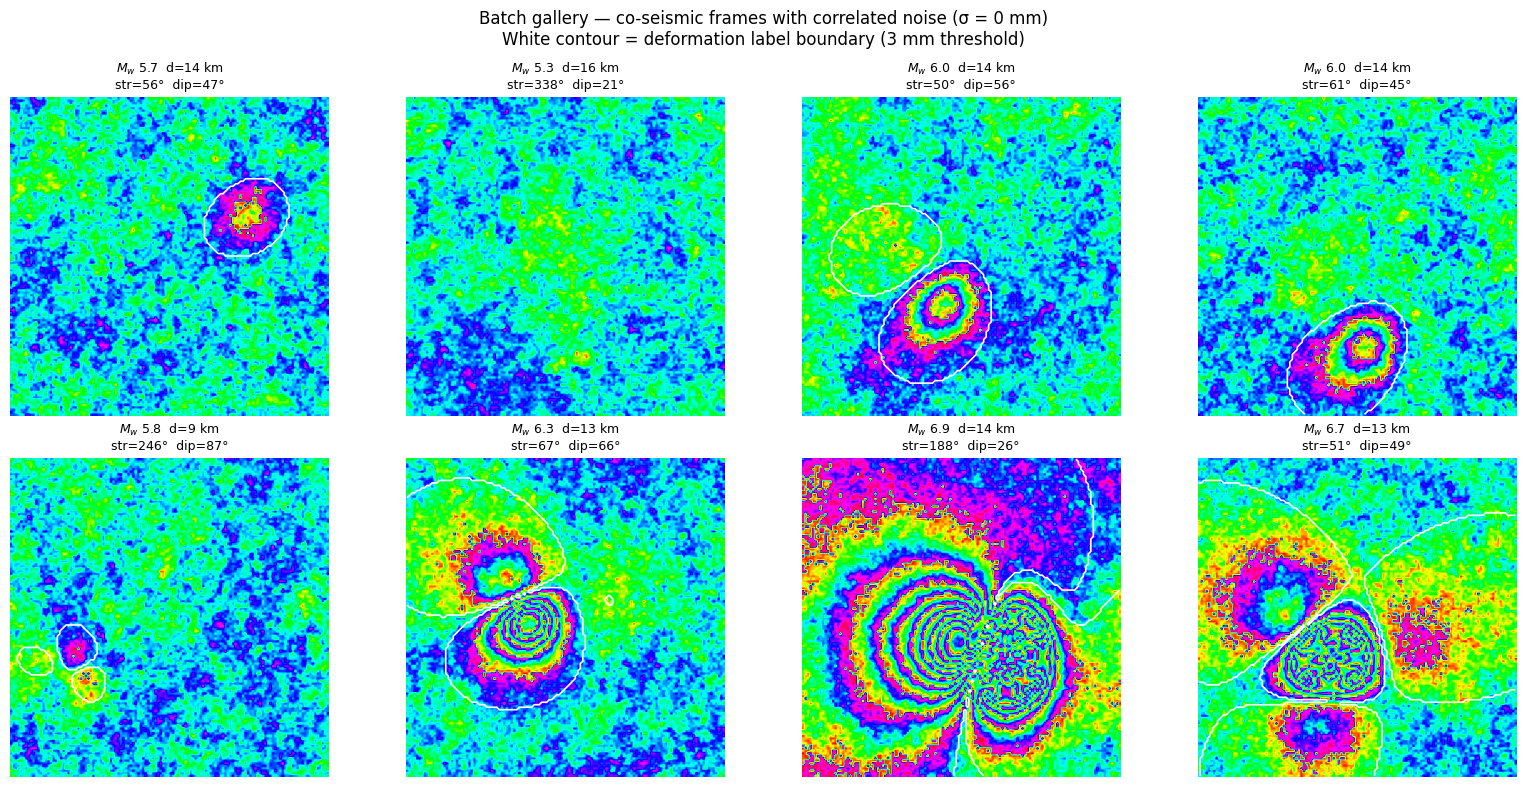

In [9]:
# Parameters — adjust as needed
N_SAMPLES   = 8
MW_RANGE    = (5, 7)
NOISE_MODEL = 'correlated'  # try 'gaussian' for comparison
NOISE_BETA  = 5/3
NOISE_AMP   = 0.003
BATCH_SEED  = 0

batch = generate_training_batch(
    n_samples=N_SAMPLES,
    mw_range=MW_RANGE,
    grid_size=128,
    satellite='sentinel1',
    n_pre=1, n_event=1, n_post=1,
    noise_model=NOISE_MODEL,
    noise_beta=NOISE_BETA,
    noise_range_m=(NOISE_AMP, NOISE_AMP),
    seed=BATCH_SEED,
    verbose=False,
)
data = batch_to_arrays(batch)

# Show the co-seismic frame (index 1: pre=1, event=1)
EVENT_FRAME = 1

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    meta = batch[i]['metadata']
    phase = data['X'][i, EVENT_FRAME]
    label = data['y'][i, EVENT_FRAME]

    # Phase as background, label as overlay
    ax.imshow(phase, cmap='hsv', vmin=-np.pi, vmax=np.pi,
              origin='lower', aspect='equal')
    # Label boundary as contour
    if label.max() > 0:
        ax.contour(label, levels=[0.5], colors='white', linewidths=1.2)

    ax.set_title(
        f"$M_w$ {meta['Mw']:.1f}  d={meta['depth_km']:.0f} km\n"
        f"str={meta['strike_deg']:.0f}°  dip={meta['dip_deg']:.0f}°",
        fontsize=9
    )
    ax.axis('off')

plt.suptitle(
    f'Batch gallery — co-seismic frames with {NOISE_MODEL} noise (σ = {NOISE_AMP*100:.0f} mm)\n'
    f'White contour = deformation label boundary (3 mm threshold)',
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## 7. Side-by-side batch comparison — Gaussian vs. Correlated

Same source parameters, same seed — only the noise model changes.

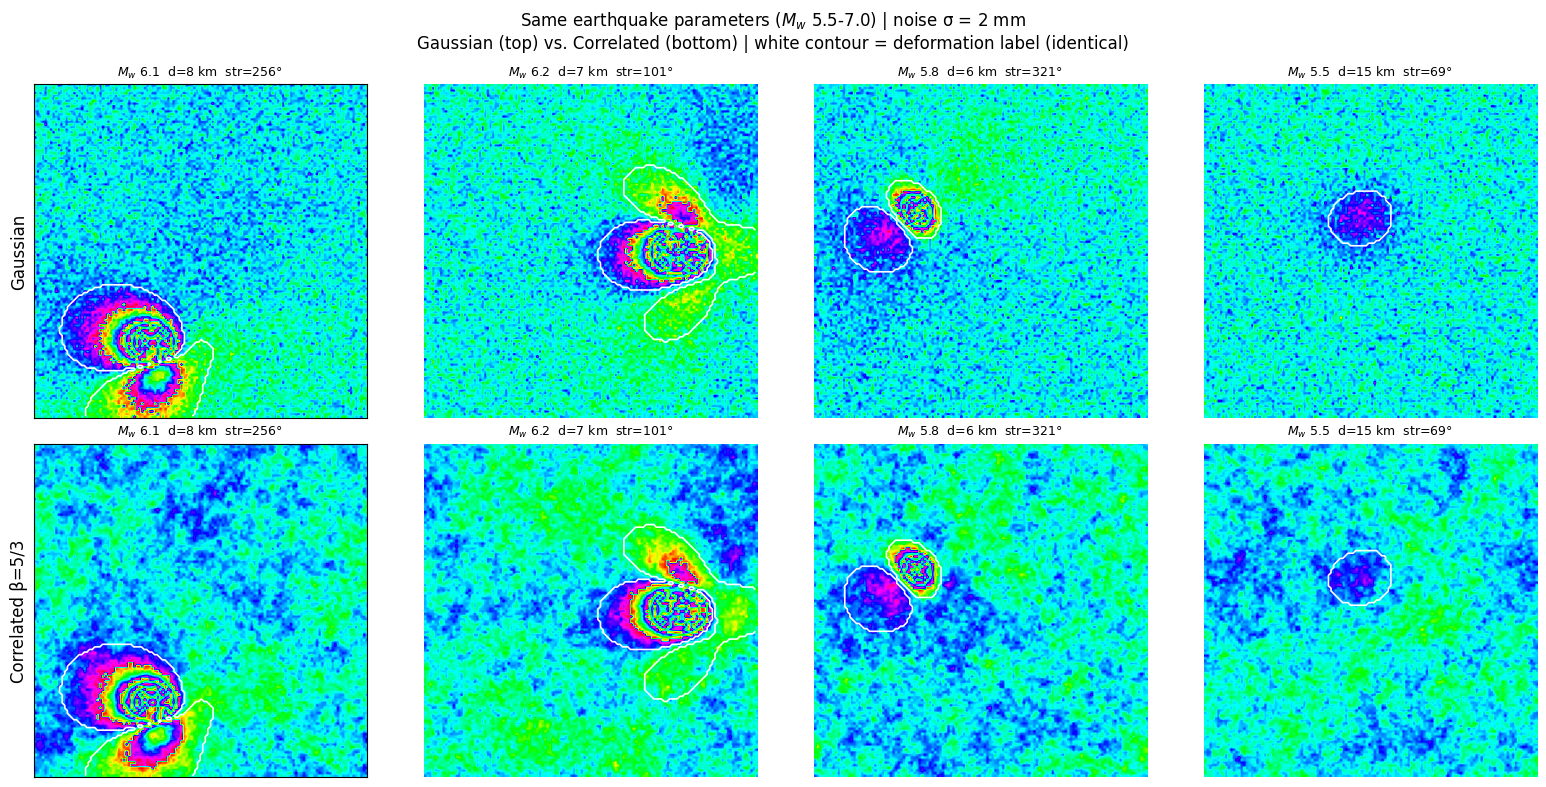

In [10]:
N_SHOW = 4
CMP_AMP = 0.002  # 2 mm — low enough to keep fringes visible in correlated row

# Generate Gaussian batch — this fixes the earthquake parameters via the random seed
batch_g = generate_training_batch(
    n_samples=N_SHOW, mw_range=(5.5, 7.0), grid_size=128, satellite='sentinel1',
    n_pre=1, n_event=1, n_post=1,
    noise_model='gaussian', noise_range_m=(CMP_AMP, CMP_AMP),
    seed=BATCH_SEED, verbose=False,
)

# Regenerate each sample with correlated noise using the exact same earthquake parameters
from eq_insar import generate_timeseries

batch_c = []
for i, sample in enumerate(batch_g):
    meta = sample['metadata']
    ts = generate_timeseries(
        Mw=meta['Mw'], strike_deg=meta['strike_deg'], dip_deg=meta['dip_deg'],
        rake_deg=meta['rake_deg'], depth_km=meta['depth_km'],
        xcen_km=meta['xcen_km'], ycen_km=meta['ycen_km'],
        satellite='sentinel1', grid_size=128,
        n_pre=1, n_event=1, n_post=1,
        noise_amplitude_m=CMP_AMP, noise_model='correlated', noise_beta=5/3,
        seed=BATCH_SEED * 100 + i,
    )
    batch_c.append({'timeseries': ts['timeseries'], 'labels': ts['labels'], 'metadata': meta})

fig, axes = plt.subplots(2, N_SHOW, figsize=(16, 8))

for i in range(N_SHOW):
    meta = batch_g[i]['metadata']
    title = f"$M_w$ {meta['Mw']:.1f}  d={meta['depth_km']:.0f} km  str={meta['strike_deg']:.0f}\u00b0"

    for row, bdata in enumerate([batch_g, batch_c]):
        phase = bdata[i]['timeseries'][EVENT_FRAME]
        label = bdata[i]['labels'][EVENT_FRAME]
        axes[row, i].imshow(phase, cmap='hsv', vmin=-np.pi, vmax=np.pi,
                            origin='lower', aspect='equal')
        if label.max() > 0:
            axes[row, i].contour(label, levels=[0.5], colors='white', linewidths=1.2)
        axes[row, i].axis('off')
        axes[row, i].set_title(title, fontsize=9)

for ax, lbl in zip(axes[:, 0], ['Gaussian', 'Correlated \u03b2=5/3']):
    ax.set_ylabel(lbl, fontsize=12)
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    f'Same earthquake parameters ($M_w$ 5.5-7.0) | noise \u03c3 = {CMP_AMP*1000:.0f} mm\n'
    'Gaussian (top) vs. Correlated (bottom) | white contour = deformation label (identical)',
    fontsize=12
)
plt.tight_layout()
plt.show()


---
## Summary

| Property | Gaussian (`noise_model='gaussian'`) | Correlated (`noise_model='correlated'`) |
|---|---|---|
| PSD | Flat (white) | Power-law $f^{-\beta}$, β = 5/3 default |
| Visual appearance | High-frequency speckle | Long-range atmospheric "haze" |
| Matches real InSAR noise | Poorly | Well (turbulent component) |
| Remaining gap to real data | — | Stratified/topographic components not modelled |
| Speed | Slightly faster | Negligibly slower (FFT-based) |
| Default (v0.2.0+) | No | **Yes** |
| Segmentation labels | Noise-independent (derived from clean signal) | Same |

**Recommendation:** Use the default `noise_model='correlated'` for ML training data  
that is intended to transfer to real Sentinel-1 interferograms. Use `noise_model='gaussian'`  
for controlled ablation studies or when fast generation speed is critical.